In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Data import CodonTable
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

def read_gene_expression(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_somatic_mutations(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_patient_metadata(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df


def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:

    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:

    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:

    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    return cph

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:

    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

Log10 split: 2.858
Exact split: 721 mutations


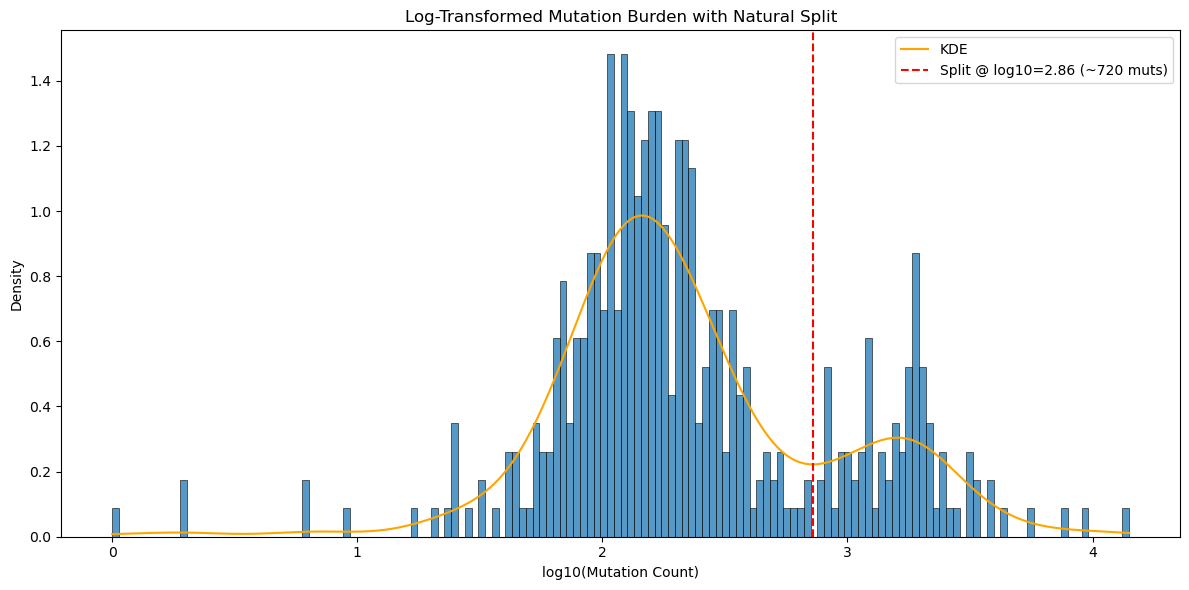

In [2]:
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
counts_array = mutation_counts[mutation_counts > 0].values.astype(float)
log_counts = np.log10(counts_array)

kde = gaussian_kde(log_counts)
x_vals = np.linspace(log_counts.min(), log_counts.max(), 1000)
kde_vals = kde(x_vals)
mask = (x_vals > 1.5) & (x_vals < 3.5)
x_zoom = x_vals[mask]
kde_zoom = kde_vals[mask]

# Find trough (local minimum)
troughs, _ = find_peaks(-kde_zoom)
if len(troughs) > 0:
    log_split = x_zoom[troughs[0]]
    exact_split = 10**log_split
    print(f"Log10 split: {log_split:.3f}")
    print(f"Exact split: {exact_split:.0f} mutations")
else:
    log_split = None
    print("No trough found.")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=150, kde=False, stat="density")
plt.plot(x_vals, kde_vals, color='orange', label='KDE')

# Plot vertical line for the split
if log_split:
    plt.axvline(log_split, color='red', linestyle='--', label=f"Split @ log10={log_split:.2f} (~{int(exact_split)} muts)")

plt.xlabel("log10(Mutation Count)")
plt.ylabel("Density")
plt.title("Log-Transformed Mutation Burden with Natural Split")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# Get histogram bin edges from the KDE-aligned plot
hist_bins = np.histogram_bin_edges(log_counts, bins=50)

# Convert log bins to linear mutation counts
linear_bins = 10 ** hist_bins

# Find the largest bin edge that is still less than the exact split
bin_aligned_split = linear_bins[linear_bins < exact_split].max()

print(f"Adjusted split (previous bin edge): {bin_aligned_split:.0f} mutations")

Adjusted split (previous bin edge): 663 mutations


In [4]:
threshold = bin_aligned_split
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
mutation_split_df = mutation_counts.to_frame(name="mutation_count")

# Assign groups
mutation_split_df["mutation_group"] = mutation_split_df["mutation_count"].apply(
    lambda x: "High" if x >= threshold else "Low"
)

# Split into patient ID lists
low_patients = mutation_split_df[mutation_split_df["mutation_group"] == "Low"].index.tolist()
high_patients = mutation_split_df[mutation_split_df["mutation_group"] == "High"].index.tolist()

# Filter original mutation rows
low_mut = somatic_mut[somatic_mut['patient_id'].isin(low_patients)]
high_mut = somatic_mut[somatic_mut['patient_id'].isin(high_patients)]

In [6]:
# gene_expr = read_gene_expression("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.expression.txt")
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
patient_meta = read_patient_metadata("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.metadata.txt")

# patient_meta['DSS']      = pd.to_numeric(patient_meta['DSS'], errors='coerce')
# patient_meta['DSS.time'] = pd.to_numeric(patient_meta['DSS.time'], errors='coerce')

# patient_meta = patient_meta.dropna(subset=['DSS', 'DSS.time'])
# patient_meta = patient_meta.dropna(subset=['gender','ajcc_pathologic_tumor_stage','histological_grade'])

# mutant_ids = somatic_mut.loc[somatic_mut['Hugo_Symbol']=='TP53','patient_id'].unique()
# patient_meta['mutation_status'] = np.where(
#     patient_meta['patient_id'].isin(mutant_ids),
#     'mutant','wildtype'
# )

# patient_meta = patient_meta.reset_index(drop=True)

In [8]:
patient_meta.dtypes

patient_id                              object
type                                    object
age_at_initial_pathologic_diagnosis    float64
gender                                  object
race                                    object
ajcc_pathologic_tumor_stage             object
histological_type                       object
histological_grade                      object
tumor_status                            object
vital_status                            object
OS                                     float64
OS.time                                float64
DSS                                    float64
DSS.time                               float64
DFI                                    float64
DFI.time                               float64
PFI                                    float64
PFI.time                               float64
Redaction                              float64
dtype: object

In [9]:
patient_meta.isnull().sum()

patient_id                               0
type                                     0
age_at_initial_pathologic_diagnosis      5
gender                                   0
race                                     0
ajcc_pathologic_tumor_stage              0
histological_type                        0
histological_grade                       0
tumor_status                            42
vital_status                             0
OS                                       0
OS.time                                  6
DSS                                     23
DSS.time                                 6
DFI                                    173
DFI.time                               175
PFI                                      0
PFI.time                                 4
Redaction                              415
dtype: int64

In [16]:
patient_meta["age_at_initial_pathologic_diagnosis"].fillna(0, inplace = True)
patient_meta["DSS"].fillna(0, inplace = True)
patient_meta["DFI"].fillna(0, inplace = True)
patient_meta["OS.time"].fillna(0, inplace = True)
patient_meta["DSS.time"].fillna(0, inplace = True)
patient_meta["DFI.time"].fillna(0, inplace = True)
patient_meta["PFI.time"].fillna(0, inplace = True)
patient_meta["race"].fillna("Unknown", inplace = True)

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_48120/1458093745.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_meta["age_at_initial_pathologic_diagnosis"].fillna(0, inplace = True)
/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_48120/1458093745.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whi

In [17]:
patient_meta.isnull().sum()

patient_id                               0
type                                     0
age_at_initial_pathologic_diagnosis      0
gender                                   0
race                                     0
ajcc_pathologic_tumor_stage              0
histological_type                        0
histological_grade                       0
tumor_status                            42
vital_status                             0
OS                                       0
OS.time                                  0
DSS                                      0
DSS.time                                 0
DFI                                      0
DFI.time                                 0
PFI                                      0
PFI.time                                 0
Redaction                              415
dtype: int64

In [104]:
patient_meta_low = patient_meta[patient_meta.patient_id.isin(low_mut.patient_id)]
patient_meta_high = patient_meta[patient_meta.patient_id.isin(high_mut.patient_id)]

In [21]:
def run_kmf(patient_meta, time, event, feature, feature1, feature2, label):
    plt.figure()
    ax = plt.subplot(111)
    m = (patient_meta[feature] == feature1)
    kmf = KaplanMeierFitter()
    kmf.fit(durations = patient_meta[m][time], event_observed = patient_meta[m][event], label = feature1)
    kmf.plot_survival_function(ax = ax)
    kmf.fit(durations = patient_meta[~m][time], event_observed = patient_meta[~m][event], label = feature2)
    kmf.plot_survival_function(ax = ax)
    plt.title(f"{label} {event} Survival of different {feature} group")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# Low mut gender

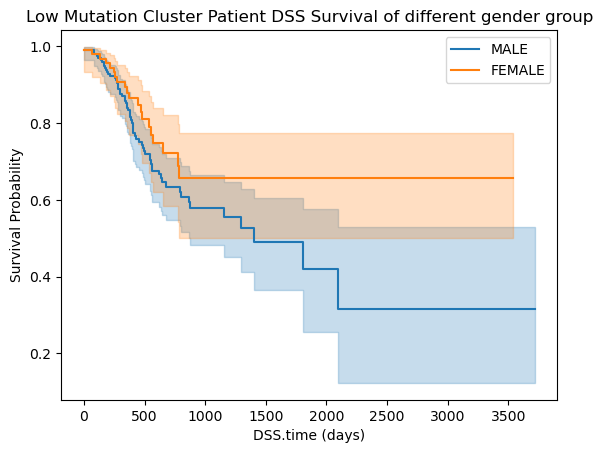

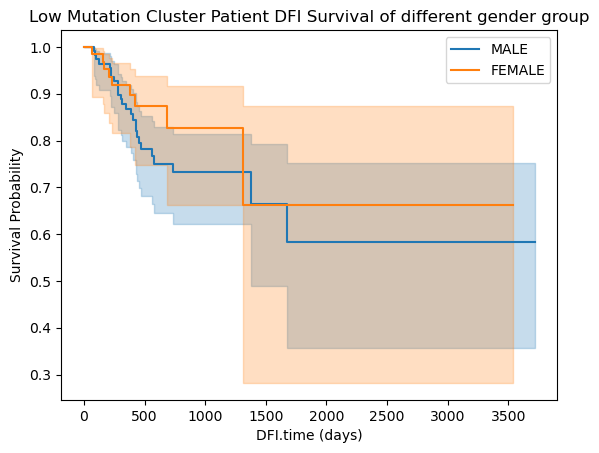

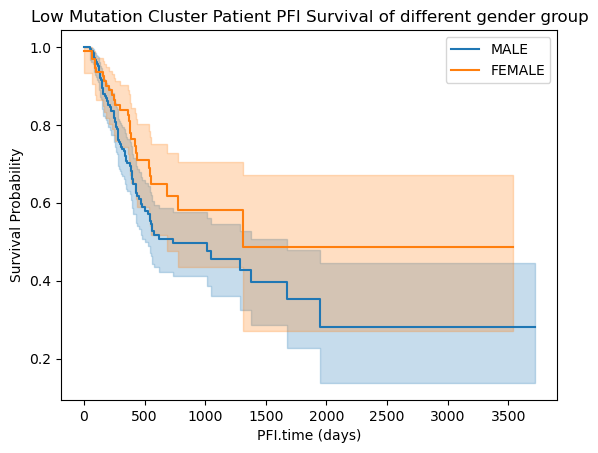

In [22]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_low, time, event, "gender", "MALE", "FEMALE", "Low Mutation Cluster Patient")

# High mut gender

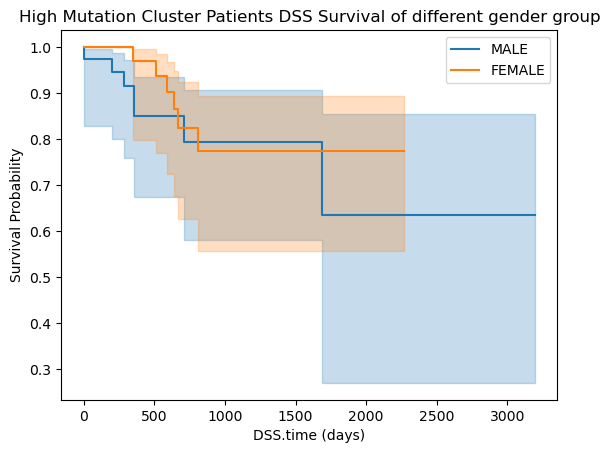

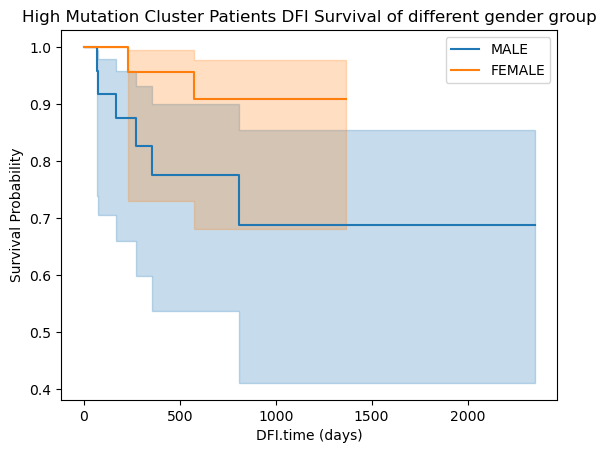

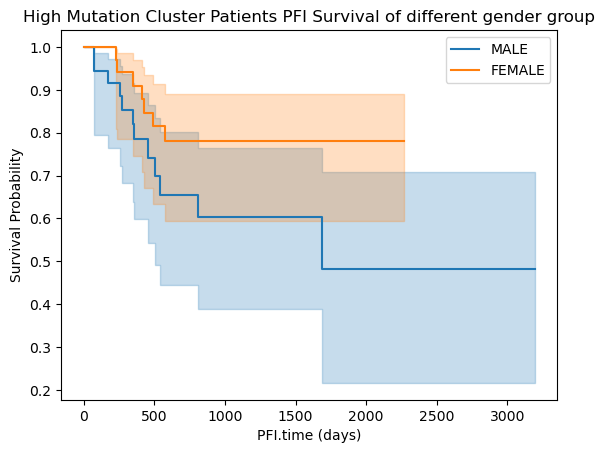

In [23]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_high, time, event, "gender", "MALE", "FEMALE", "High Mutation Cluster Patients")

# low mut Tumor status

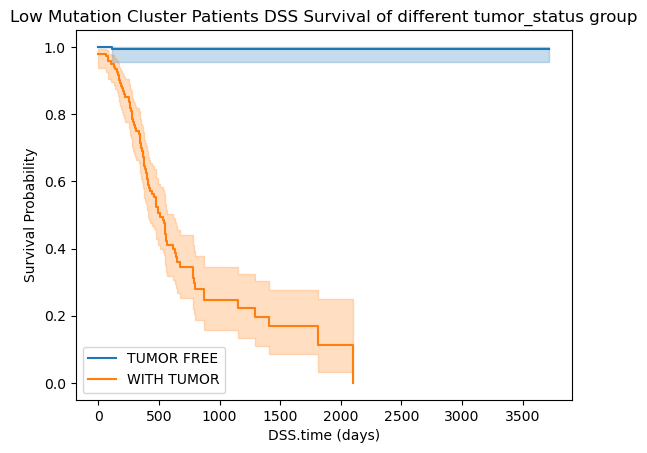

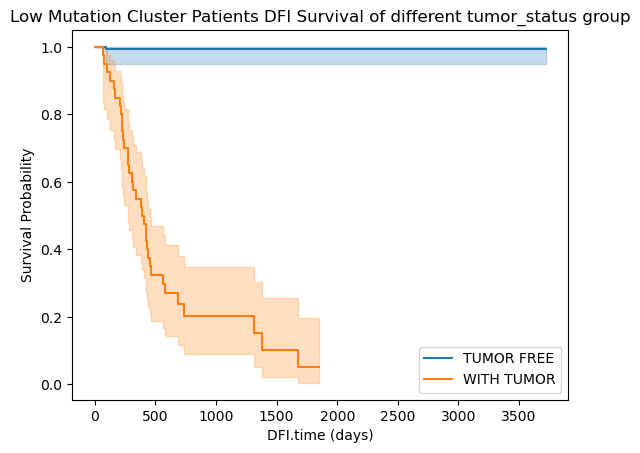

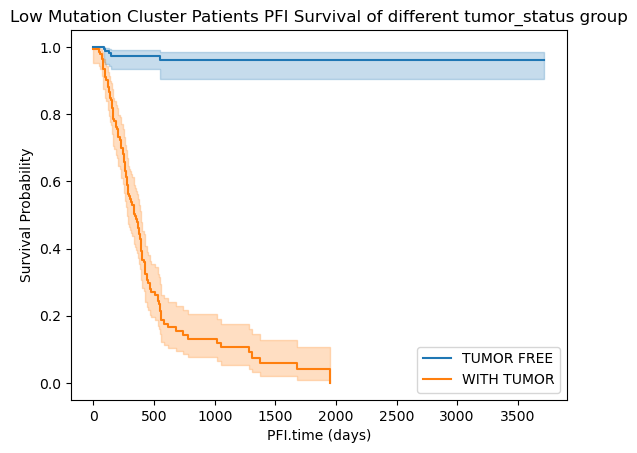

In [24]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_low, time, event, "tumor_status", "TUMOR FREE", "WITH TUMOR", "Low Mutation Cluster Patients")

# High mut tumor status

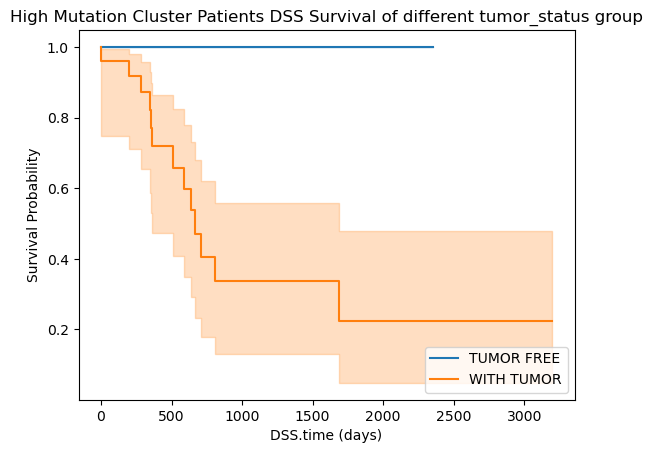

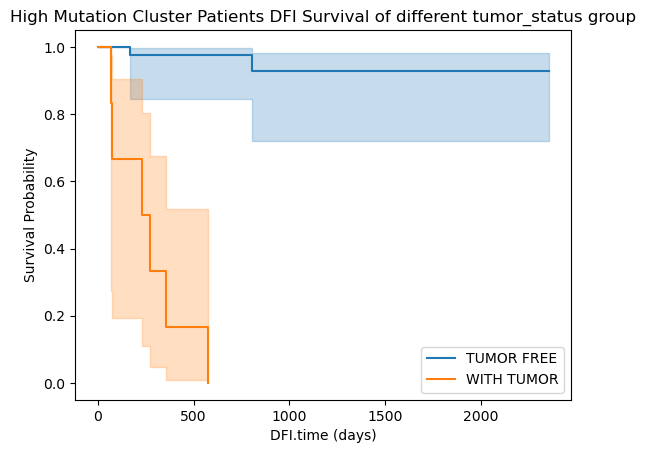

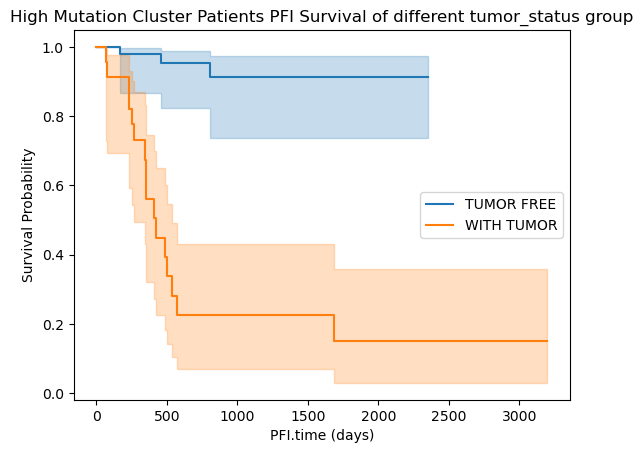

In [25]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_high, time, event, "tumor_status", "TUMOR FREE", "WITH TUMOR", "High Mutation Cluster Patients")

# Separate by race

In [26]:
races = ['ASIAN', 'BLACK OR AFRICAN AMERICAN', 'WHITE']
patient_meta_race = patient_meta[patient_meta.race.isin(races)]

In [27]:
patient_meta_race_low_mut = patient_meta_low[patient_meta_low.race.isin(races)]
patient_meta_race_high_mut = patient_meta_high[patient_meta_high.race.isin(races)]

# Low mut race

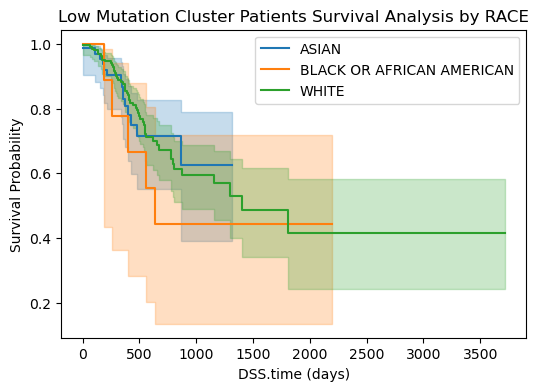

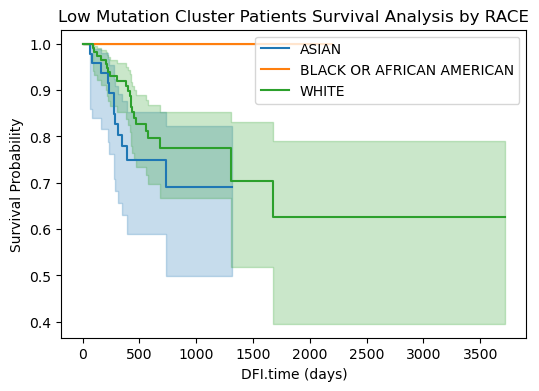

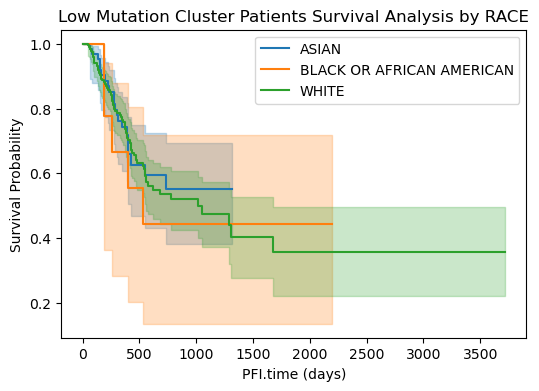

In [28]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_low_mut.groupby('race'):
        kmf.fit(sub[time], event_observed=sub[event], label=grp)
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"Low Mutation Cluster Patients Survival Analysis by RACE")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# High mut race

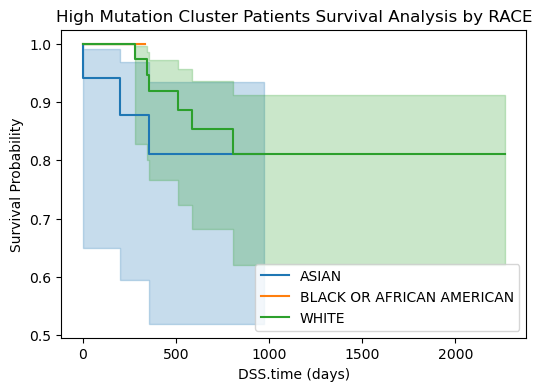

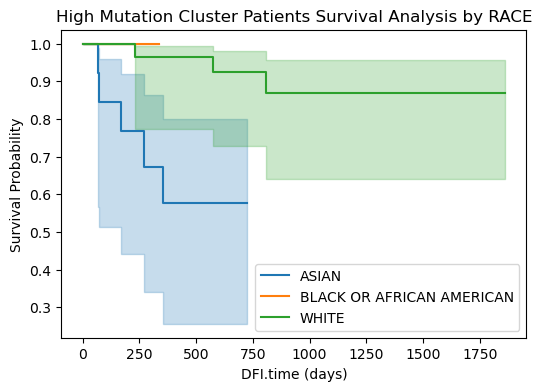

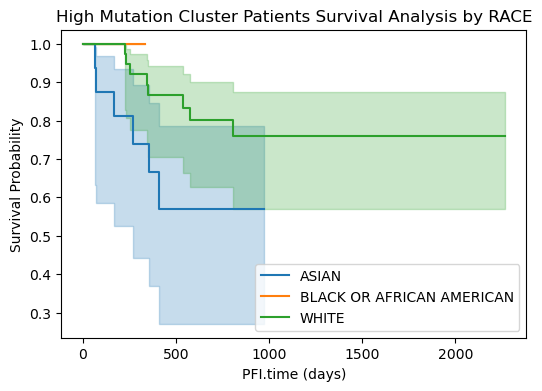

In [29]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_high_mut.groupby('race'):
        kmf.fit(sub[time], event_observed=sub[event], label=grp)
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"High Mutation Cluster Patients Survival Analysis by RACE")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# COX proportional

<lifelines.CoxPHFitter: fitted with 357 total observations, 275 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 357
number of events observed = 82
   partial log-likelihood = -420.19
         time fit was run = 2025-05-30 21:05:00 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
age_at_initial_pathologic_diagnosis  0.00      1.00      0.01           -0.02            0.03                0.98                1.03
gender_MALE                          0.47      1.60      0.25           -0.02            0.96                0.98                2.62
race_BLACK OR AFRICAN AMERICAN       0.33      1.40      0.52           -0.69            1.35                0.50                3.87
race_WHITE                          -0.06      0.94      0.27           -0.59            0.47                0.55                1.60

                                     cmp to     z    p  -log2(p)
covariate                                                       
age_at_initial_pathologic_diagnosis    0.00  0.41 0.68      0.55
gender_MALE                            0.00  1.88 0.06      4.05
race_BLACK OR AFRICAN AMERICAN         0.00  0.64 0.52      0.94
race_WHITE                             0.00 -0.23 0.82      0.29
---
Concordance = 0.57
Partial AIC = 848.39
log-likelihood ratio test = 4.92 on 4 df
-log2(p) of ll-ratio test = 1.76

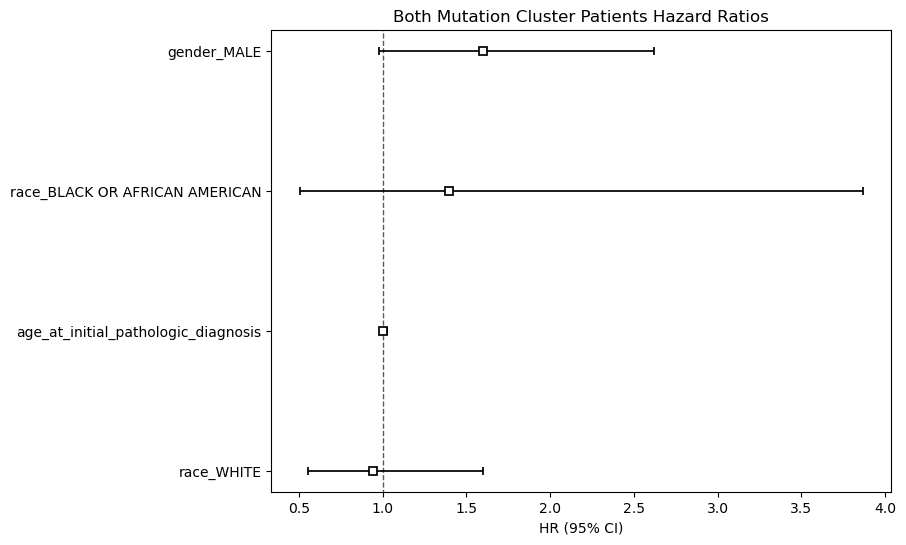

In [30]:
cph = cox_proportional_hazards(
    patient_meta_race,
    time_col   = 'DSS.time',
    event_col  = 'DSS',
    numeric_covs     = ['age_at_initial_pathologic_diagnosis'],
    categorical_covs = ['gender','race']
)

cph.print_summary()

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Both Mutation Cluster Patients Hazard Ratios")
plt.show()

In [154]:
from lifelines.statistics import proportional_hazard_test
from statsmodels.stats.multitest import multipletests

def annotate_genes(somatic_mut, patient_meta, gene_list):

    def add_mutation_status_column(df, gene_col, mutation_gene):
        df = df.copy()
        df[f'{gene}_mutation_status'] = np.where(df[gene_col] == mutation_gene, 1, 0)
        return df

    for gene in gene_list:
        somatic_mut = add_mutation_status_column(somatic_mut, 'Hugo_Symbol', gene)
        patient_meta = patient_meta.copy()
        patient_meta[f'{gene}_mutation_status'] = np.where(
            patient_meta['patient_id'].isin(
                somatic_mut[somatic_mut[f'{gene}_mutation_status']==1]['patient_id']),
            1, 0)
        
    column_to_use = [f"{gene}_mutation_status" for gene in gene_list] + ["patient_id", "DSS", "DSS.time"]
    annotated_patient_meta = patient_meta[column_to_use]
    annotated_patient_meta = annotated_patient_meta.set_index('patient_id')
    return somatic_mut, annotated_patient_meta
    

def cox_hazard_test(data, time, event):
    min_mutated_patients = 5
    mutation_cols = [col for col in data.columns if col.endswith('_mutation_status')]
    sufficient = [col for col in mutation_cols if data[col].sum() >= min_mutated_patients]
    filtered_data = data[sufficient + [time, event]]
    
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(filtered_data, duration_col = time, event_col = event)
    results = proportional_hazard_test(cph, filtered_data)
    results_df = results.summary
    pvals = results_df['p'].values
    rejected, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    results_df['FDR_corrected_p'] = pvals_corrected
    return cph, results_df

In [158]:
top = 1000
top_genes = (
    somatic_mut['Hugo_Symbol']
    .value_counts()
    .nlargest(top)
    .index
    .tolist()
)

mutation_matrix = (
    somatic_mut[somatic_mut['Hugo_Symbol'].isin(top_genes)]
    .drop_duplicates(subset=['patient_id', 'Hugo_Symbol'])  # 1 if mutated
    .assign(value=1)
    .pivot(index='patient_id', columns='Hugo_Symbol', values='value')
    .fillna(0)
    .astype(int)
)

mutation_matrix.columns = [f"{col}_mutation_status" for col in mutation_matrix.columns]

column_to_use = [f"{gene}_mutation_status" for gene in top_genes] + ["DSS", "DSS.time"]

patient_meta_low = patient_meta_low.set_index('patient_id')
patient_meta_high = patient_meta_high.set_index('patient_id')

annotated_patient_meta_low = patient_meta_low.join(mutation_matrix, how='left').fillna(0)
annotated_patient_meta_high = patient_meta_high.join(mutation_matrix, how='left').fillna(0)

low_selected = annotated_patient_meta_low[column_to_use]
high_selected = annotated_patient_meta_high[column_to_use]

In [124]:
cph_low, low_mut_results = cox_hazard_test(low_selected, "DSS.time", "DSS")
cph_high, high_mut_results = cox_hazard_test(high_selected, "DSS.time", "DSS")

In [163]:
low_mut_results.to_csv("low_mut_results.tsv", sep='\t', index=True)
high_mut_results.to_csv("high_mut_results.tsv", sep='\t', index=True)

In [165]:
low_mut_results[low_mut_results.FDR_corrected_p < 0.05]

,test_statistic,p,-log2(p),FDR_corrected_p
BRCA2_mutation_status,11.507273,0.000693,10.494349,0.042319
COL27A1_mutation_status,16.410536,0.000051,14.259116,0.013072
CREBBP_mutation_status,11.255217,0.000794,10.298582,0.042319
FIGN_mutation_status,14.690329,0.000127,12.946356,0.020784
GNAS_mutation_status,11.926988,0.000553,10.819740,0.042319
GPR179_mutation_status,13.114040,0.000293,11.736364,0.033119
KCNMA1_mutation_status,11.144909,0.000843,10.212820,0.042319
LRP5_mutation_status,11.369588,0.000747,10.387446,0.042319
NFATC2_mutation_status,20.179402,0.000007,17.113780,0.006374
PBRM1_mutation_status,14.098714,0.000173,12.493090,0.022401


In [173]:
selected = ['STAB1', 'TNS3', 'NFATC2', 'COL27A1']

In [126]:
high_mut_results[high_mut_results.FDR_corrected_p < 0.05]

,test_statistic,p,-log2(p),FDR_corrected_p


In [127]:
potential_gene_list_low = [gene.split("_mutation_status")[0] for gene in low_mut_results[low_mut_results.FDR_corrected_p < 0.05].index]
# potential_gene_list_high = 

In [169]:
patient_meta_low = patient_meta[patient_meta.patient_id.isin(low_mut.patient_id)]
annotated_somatic_mut, annotated_patient_meta_low = annotate_genes(somatic_mut, patient_meta_low, potential_gene_list_low)
cph_low, low_mut_results = cox_hazard_test(annotated_patient_meta_low, "DSS.time", "DSS")

<Axes: xlabel='log(HR) (95% CI)'>

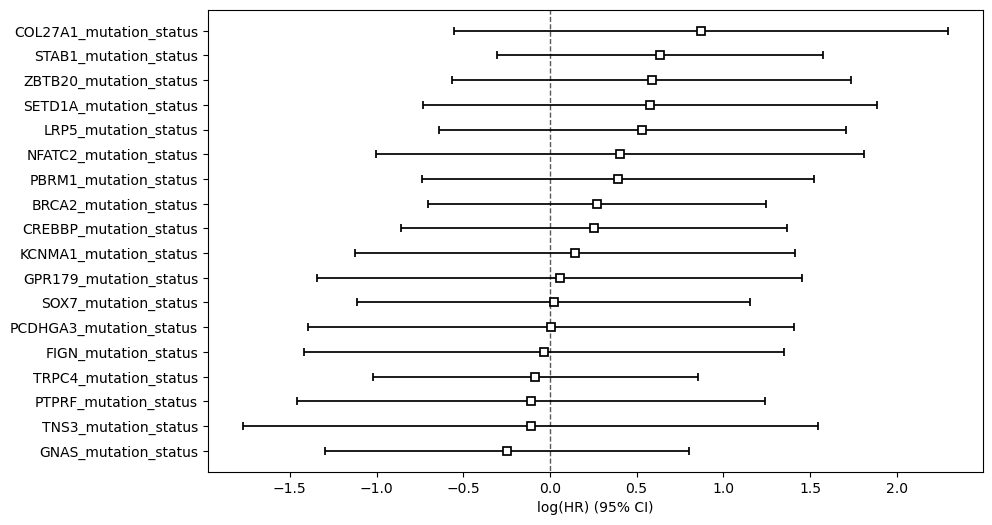

In [170]:
plt.subplots(figsize = (10, 6))
cph_low.plot()

ASIAN


<Figure size 600x400 with 0 Axes>

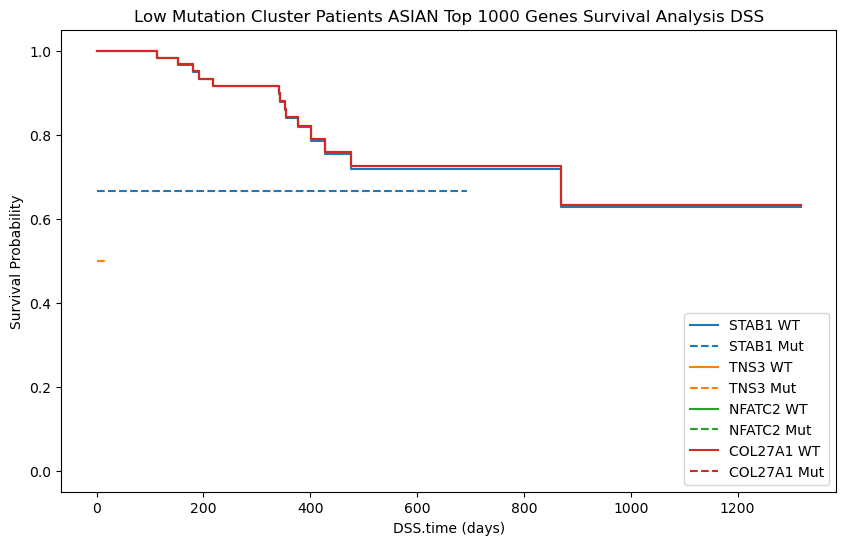

WHITE


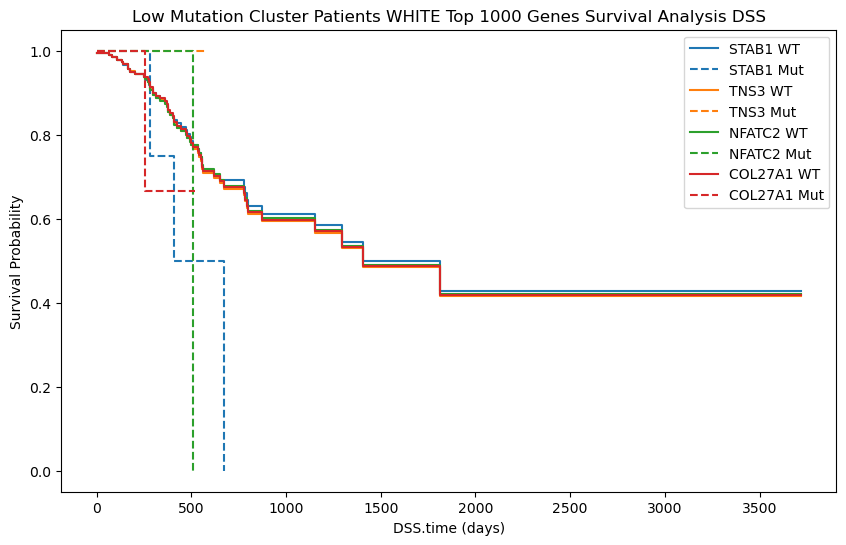

In [177]:
for time,event in [["DSS.time", "DSS"]]:
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_low_mut.groupby('race'):
        if grp in ['ASIAN', 'WHITE']:
            print(grp)
            top_genes_kmf(sub, somatic_mut, selected, f"Low Mutation Cluster Patients {grp} Top {top} Genes", event, time)

<Axes: >

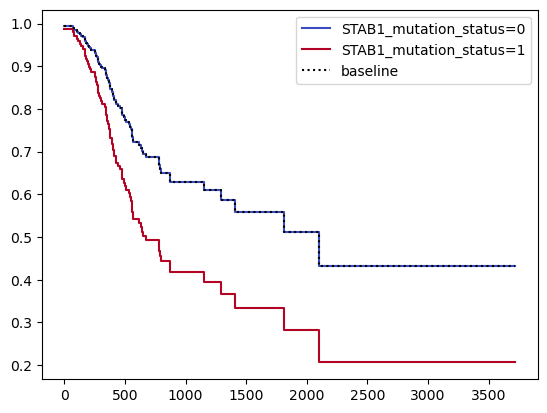

In [179]:
cph_low.plot_partial_effects_on_outcome(covariates = 'STAB1_mutation_status', values = [0,1], cmap = 'coolwarm')

<Axes: >

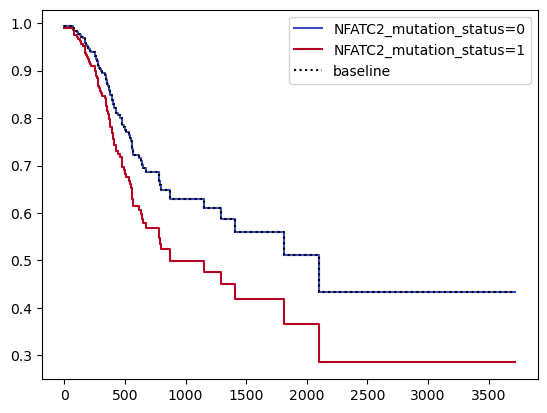

In [181]:
cph_low.plot_partial_effects_on_outcome(covariates = 'NFATC2_mutation_status', values = [0,1], cmap = 'coolwarm')

# Top genes but looking at them separated by race

In [171]:
def top_genes_kmf(patient_meta, somatic_mut, top_genes, label, event, time):
    colors = plt.cm.tab10.colors
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, gene in enumerate(top_genes):
        # mark mutation status
        patient_meta[f'{gene}_mut'] = np.where(
            patient_meta['patient_id'].isin( 
                somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
            ),
            1, 0
        )

        color = colors[i % len(colors)]
        # plot Wild-Type
        wt = patient_meta[patient_meta[f'{gene}_mut'] == 0]
        kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=color, linestyle='-')
        # plot Mutant
        mut = patient_meta[patient_meta[f'{gene}_mut'] == 1]
        kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=color, linestyle='--')
    
    plt.title(f"{label} Survival Analysis {event}")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

In [235]:
patient_meta_race.race.value_counts()

race
WHITE                        242
ASIAN                         83
BLACK OR AFRICAN AMERICAN     12
Name: count, dtype: int64

# Low mut top frequent genes

ASIAN


<Figure size 600x400 with 0 Axes>

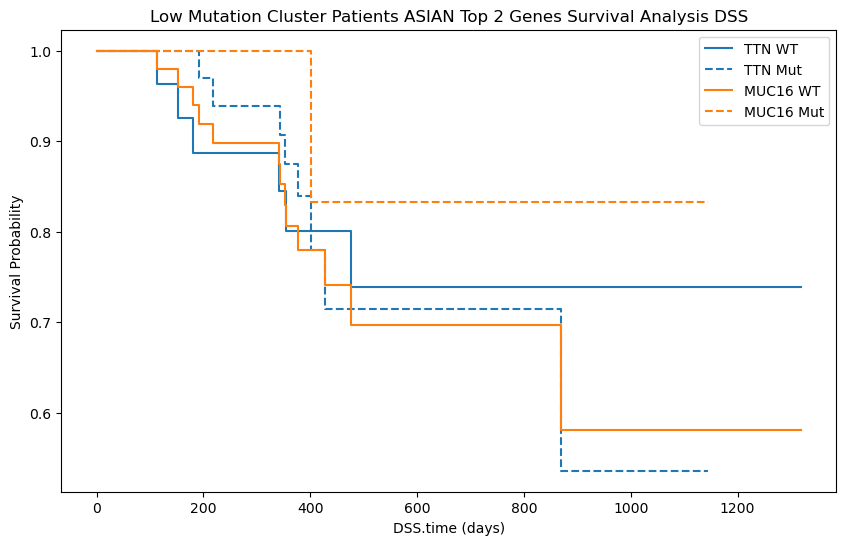

BLACK OR AFRICAN AMERICAN


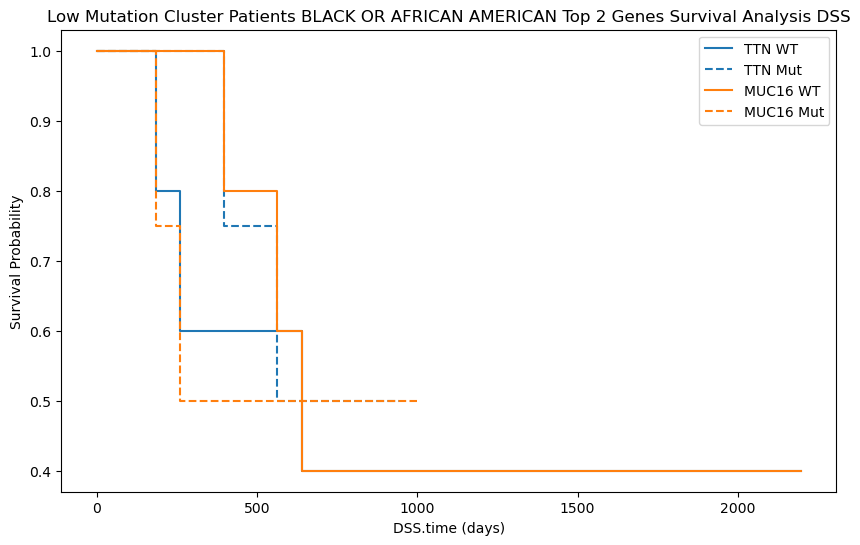

WHITE


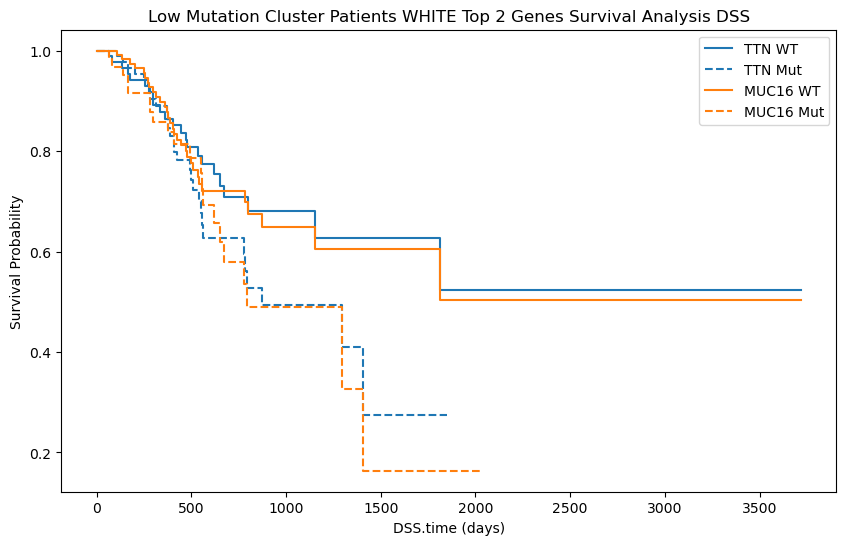

ASIAN


<Figure size 600x400 with 0 Axes>

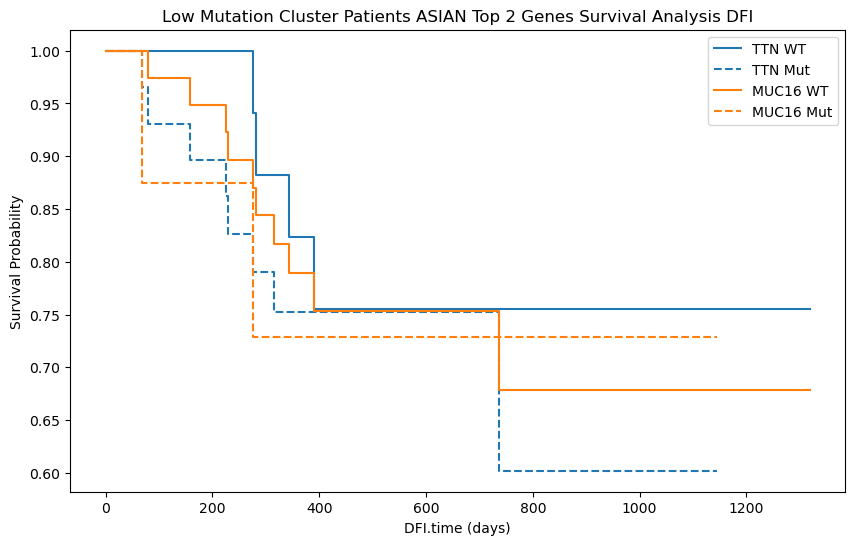

BLACK OR AFRICAN AMERICAN


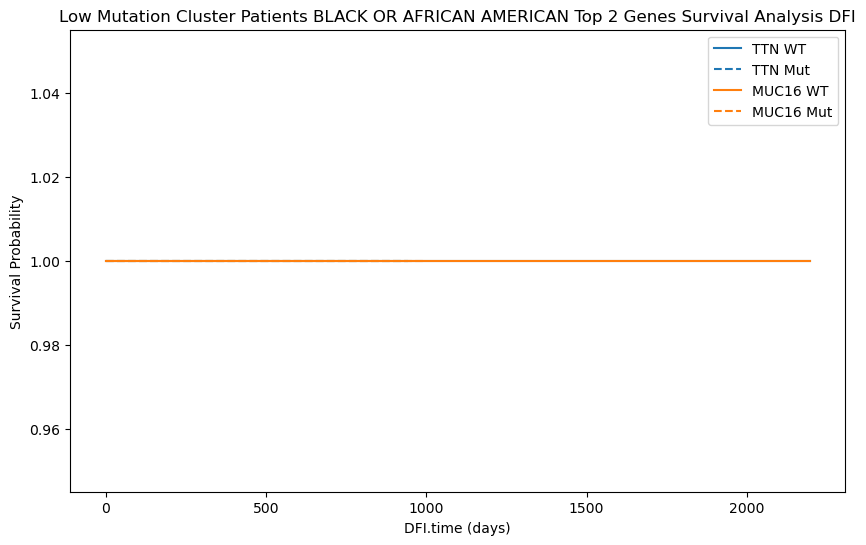

WHITE


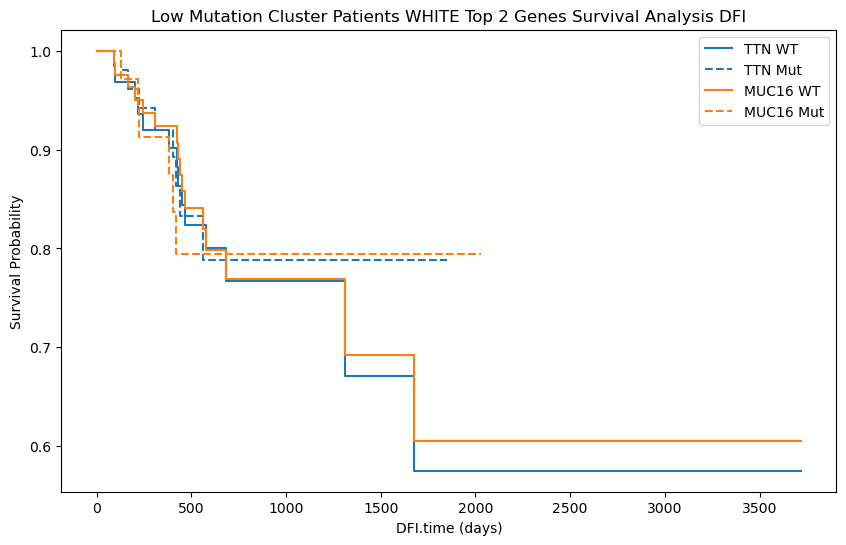

ASIAN


<Figure size 600x400 with 0 Axes>

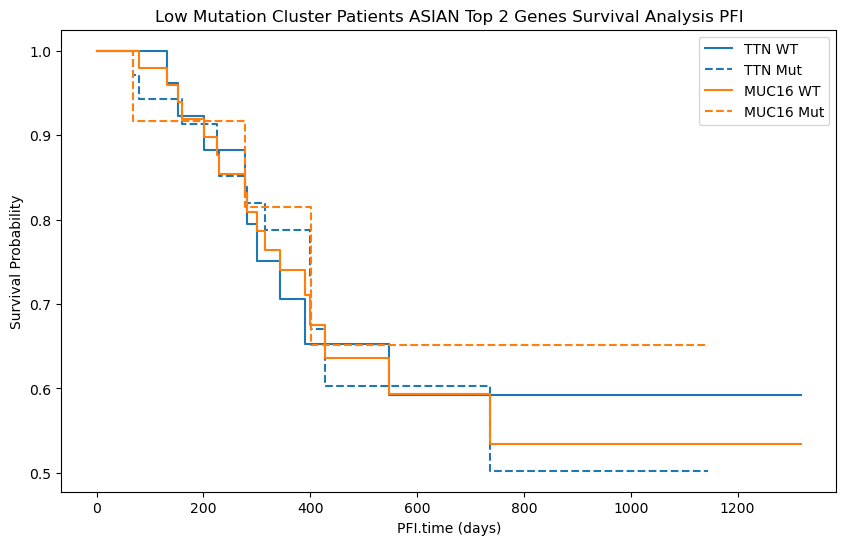

BLACK OR AFRICAN AMERICAN


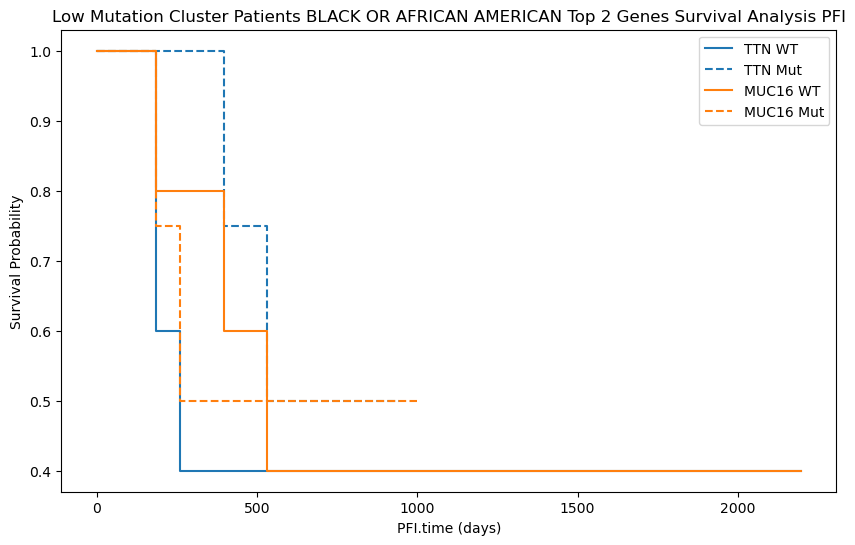

WHITE


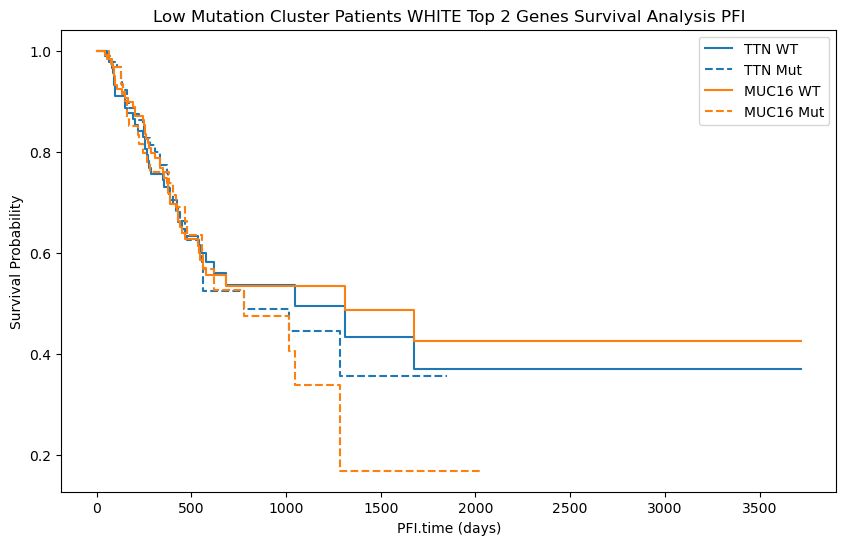

In [244]:
top = 2
top_genes = (
    somatic_mut['Hugo_Symbol']
    .value_counts()
    .nlargest(top)
    .index
    .tolist()
)

for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_low_mut.groupby('race'):
        print(grp)
        top_genes_kmf(sub, somatic_mut, top_genes, f"Low Mutation Cluster Patients {grp} Top {top} Genes", event, time)

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3717744076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_low_mut[f'{gene}_mut'] = np.where(
/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3717744076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_low_mut[f'{gene}_mut'] = np.where(


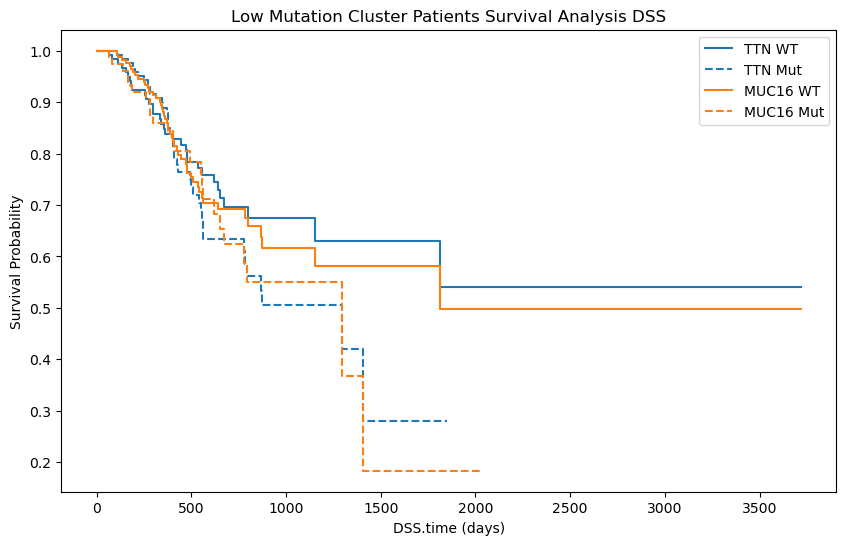

In [248]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(top_genes):
    # mark mutation status
    patient_meta_race_low_mut[f'{gene}_mut'] = np.where(
        patient_meta_race_low_mut['patient_id'].isin( 
            somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
        ),
        1, 0
    )

    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = patient_meta_race_low_mut[patient_meta_race_low_mut[f'{gene}_mut'] == 0]
    kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = patient_meta_race_low_mut[patient_meta_race_low_mut[f'{gene}_mut'] == 1]
    kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"Low Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

# High mut top frequent genes

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3163423188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_high_mut[f'{gene}_mut'] = np.where(
/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3163423188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_high_mut[f'{gene}_mut'] = np.where(


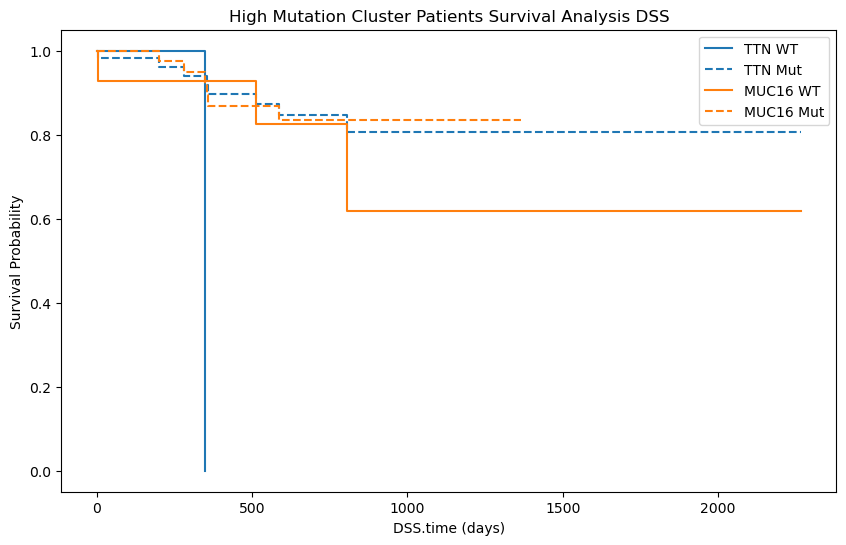

In [247]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(top_genes):
    # mark mutation status
    patient_meta_race_high_mut[f'{gene}_mut'] = np.where(
        patient_meta_race_high_mut['patient_id'].isin( 
            somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
        ),
        1, 0
    )

    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = patient_meta_race_high_mut[patient_meta_race_high_mut[f'{gene}_mut'] == 0]
    kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = patient_meta_race_high_mut[patient_meta_race_high_mut[f'{gene}_mut'] == 1]
    kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"High Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

# Low mut top hazard significant genes

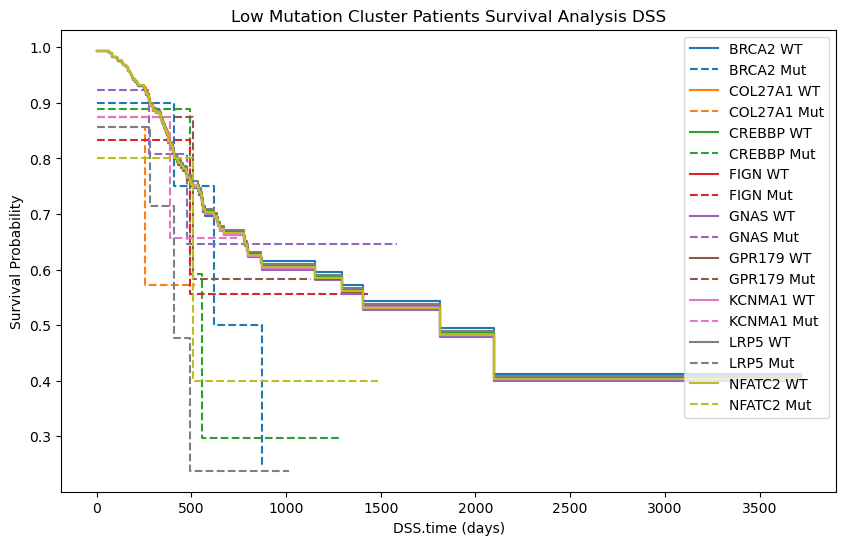

In [147]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(potential_gene_list_low[:9]):
    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = low_selected[low_selected[f'{gene}_mutation_status'] == 0]
    kmf.fit(wt["DSS.time"], event_observed=wt["DSS"], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = low_selected[low_selected[f'{gene}_mutation_status'] == 1]
    kmf.fit(mut["DSS.time"], event_observed=mut["DSS"], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"Low Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

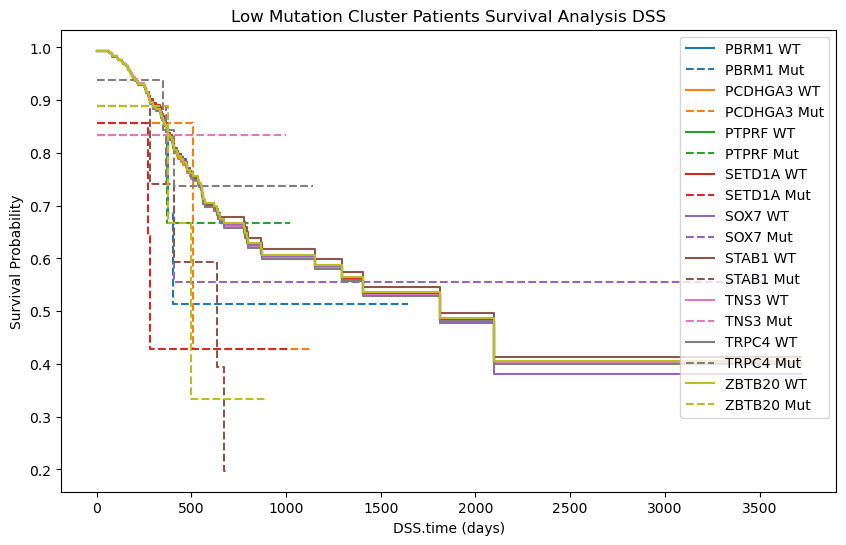

In [148]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(potential_gene_list_low[9:]):
    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = low_selected[low_selected[f'{gene}_mutation_status'] == 0]
    kmf.fit(wt["DSS.time"], event_observed=wt["DSS"], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = low_selected[low_selected[f'{gene}_mutation_status'] == 1]
    kmf.fit(mut["DSS.time"], event_observed=mut["DSS"], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"Low Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

# High mut top hazard significant genes

In [ ]:
# colors = plt.cm.tab10.colors
# kmf = KaplanMeierFitter()
# fig, ax = plt.subplots(figsize=(10, 6))

# for i, gene in enumerate(potential_gene_list_high):
#     color = colors[i % len(colors)]
#     # plot Wild-Type
#     wt = patient_meta_high[patient_meta_high[f'{gene}_mutation_status'] == 0]
#     kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
#     kmf.plot_survival_function(ax=ax, ci_show=False,
#                                color=color, linestyle='-')
#     # plot Mutant
#     mut = patient_meta_high[patient_meta_high[f'{gene}_mutation_status'] == 1]
#     kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
#     kmf.plot_survival_function(ax=ax, ci_show=False,
#                                color=color, linestyle='--')

# plt.title(f"High Mutation Cluster Patients Survival Analysis DSS")
# plt.xlabel(f"DSS.time (days)")
# plt.ylabel("Survival Probability")
# plt.show()